##### lerobot の キューブの手渡しの model ACT(lerobot/aloha_sim_transfer_cube_human) を使った、学習用の pytorch コードです。  
学習データは、実際のデータを huggingface からダウンロードして使います。  
複雑な、lerobot の train を、自分で model class を使ってtrain することの材料になれば、幸いです。  
  
本コードを作成するにあたっては、Google Ai に、大変手助けをもらいました。  
ありがとうと、感謝します。  
#### シュミレータは、gym_aloha/AlohaTransferCube-v0 が使えます。  
Demo で、確認できる。  
  
$ export PYTHONPATH=$PYTHONPATH:/home/your-id/local/git-download/lerobot/src  
$ python src/lerobot/scripts/lerobot_dataset_viz.py \  
  --repo-id lerobot/aloha_sim_transfer_cube_human \  
  --episode-index 0



In [1]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
# git clone をした、パスを使ってください。
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.lerobot_train import train
from lerobot.configs.policies import PreTrainedConfig

import torch.nn.functional as F

batch_size=2

### オリジナルの ACT class(aloha_sim_transfer_cube_human) を、使います。  
lerobot/src/lerobot/policies/act/modeling_act.py  
class ACT(nn.Module):  
inputs:  
camera 入力が、1 個になります。  
アームのセンサーは、同じ 14 個 だと思う。  
outputs:  
アームの 14 個のサーボの位置を示す数値データ。  

In [2]:
import torch
# 公式の policy（モデル）から直接インポートします
from lerobot.policies.act.modeling_act import ACT
from lerobot.policies.act.configuration_act import ACTConfig

from lerobot.configs.types import FeatureType
from lerobot.configs.policies import PolicyFeature

# 1. 公式の「設定シート」を作ります
config = ACTConfig(
    device="cuda",
    n_action_steps=100,
    input_features={
        "observation.environment_state": PolicyFeature(
            type=FeatureType.STATE,
            shape=(14,)
        ),
        #"observation.images.top": PolicyFeature(
        #    type=FeatureType.VISUAL,
        #    shape=(3, 480, 640)
        #),
        "observation.images": PolicyFeature(
            type=FeatureType.VISUAL,
            shape=(3, 480, 640)
        ),
    },
    output_features={
        "action": PolicyFeature(
            type=FeatureType.ACTION,
            shape=(14,)
        )
    },
    n_encoder_layers=4,
    n_decoder_layers=7,
    dim_model=512,
    dim_feedforward=3200,
)

# 1. 脳（SimpleACT）の準備
#device = "cuda" if torch.cuda.is_available() else "cpu"
#model = ACT(config).to(device)

### dataset に delta_timestamps を挿入します。  
「ACTモデルの真価を発揮するため、現在から未来100ステップ分（約2秒間）の動作を一気に学習するように設定しました。
これにより、一貫性のある滑らかな動きが可能になります。」


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

img.shape: torch.Size([480, 640, 3])


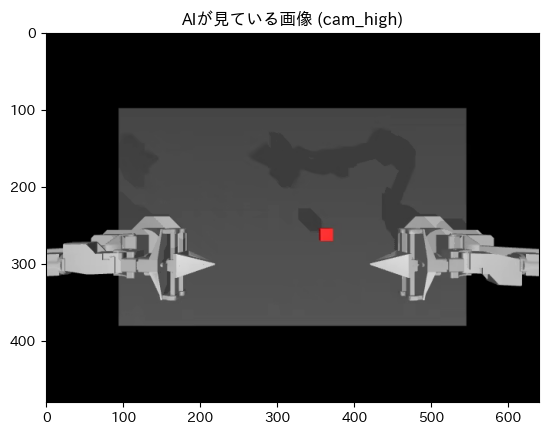

In [3]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

from lerobot.datasets.lerobot_dataset import LeRobotDataset
# データセットを直接読み込む
#dataset = LeRobotDataset("lerobot/aloha_static_pingpong_test")

DATASET_ID = "lerobot/aloha_sim_transfer_cube_human"
# データセットを作るコードを探して、delta_timestamps を追加します
dataset = LeRobotDataset(
    DATASET_ID,
    delta_timestamps={"action": [i/50 for i in range(100)]} # 50Hzなので /50
)

if True:
    # 最初の1コマ（1ステップ分）をのぞき見
    frame = dataset[0]
    #print('frame.keys():',frame.keys())
    # model inputs は、(3,480,640) で、色順は、RGB です。
    # plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
    # 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
    img = frame["observation.images.top"].permute(1, 2, 0)
    print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
    plt.imshow(img)
    plt.title("AIが見ている画像 (cam_high)")
    plt.show()


In [4]:
from torch.utils.data import DataLoader

# 1. 教科書（DataLoader）の準備
# num_workers=0 は先ほどのエラー回避のためです
train_loader = DataLoader(
    dataset, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=0
)

from torchvision import transforms
# 1. 特訓メニュー（オーグメンテーション）の定義
train_transform = transforms.Compose([
    # 明るさ、コントラスト、彩度、色相をランダムに変える（照明変化への耐性）
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    # ランダムに少しだけぼかす（レンズの汚れやピントズレへの耐性）
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.3), 
    # --- ここを追加！ ---
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # 赤・緑・青の平均値
        std=[0.229, 0.224, 0.225]   # 標準偏差
    )
])


In [ ]:
#2. 特訓ループ：1コマの「完コピ」実験
import torch.optim as optim
import torch
import numpy as np
from torch.optim.lr_scheduler import LambdaLR

out_dir="output/train_act"
# 出力先のクラスフォルダを作成
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
best_path = os.path.join(out_dir, "best_model.pth")
epoch_best_path = os.path.join(out_dir, "epoch_best_model.pth")

# 1. 脳（SimpleACT）の準備
device = "cuda" if torch.cuda.is_available() else "cpu"
# --- モデルは14軸で再構築 ---
model = ACT(config).to(device)
model.train()

#num_epochs=201
num_epochs=4
#num_epochs=1

# 2. 工具（Optimizer）の設定
# 1コマ集中特訓なので、少し強めの学習率(1e-4)で一気に覚えさせます
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
num_warmup_steps = 200     # 最初の200回は徐々に体慣らし
num_training_steps = 1500  # 合計1500ステップ特訓

def lr_lambda(current_step: int):
    if current_step < num_warmup_steps:
        return float(current_step) / float(max(1, num_warmup_steps))
    return 1.0
scheduler = LambdaLR(optimizer, lr_lambda)

print(f"特訓開始 (Device: {device})...")
losses = []

best_loss = float('inf')
step_best_loss = float('inf')

min_loss=0.1
counter=0
steps=0
for epoch in range(num_epochs):
    total_loss = 0
    losses = []
    for step,batch_data in enumerate(train_loader):
        # データを整理してGPUへ
        #print('batch_data:',batch_data)
        # observation.images.top
        #img = batch_data["observation.images.cam_high"].to(device)
        # batch_data から画像を取り出した直後に適用
        img_raw = batch_data["observation.images.top"].to(device)
        img_augmented = train_transform(img_raw)
        
        state = batch_data["observation.state"].to(device)
        # 未来100ステップの正解
        target = batch_data["action"].to(device)
        #print('target.shape:',target.shape)
        # batch_data の中身
        #target = batch_data["action"]        # [Batch, 100, 14]（最後は同じ値が並ぶ）
        is_pad = batch_data["action_is_pad"].to(device) # [Batch, 100]（本物ならFalse, 埋めた場所はTrue）
        
        # --- 学習の4ステップ ---
        # A. 予測
        #pred = model(img_raw, state)
        #pred = model(img_augmented, state)
        if False:
            batch = {
                "observation.images.top": img_augmented,   # [B,3,H,W]
                "observation.environment_state": state,    # [B,14]
                #"action": action,                         # [B,T,14] or [B,14]
                "action": target,
            }
        else:
            batch = {
                #"observation.images.top": img_augmented,
                "observation.images": [img_augmented],   # [B,3,H,W]
                "observation.state": state,              # [B,14]
                "observation.environment_state": state,
                "action": target,                        # # [B,T,14] or [B,14]
                # False = valid token
                #"action_is_pad": torch.zeros(
                #    target.shape[:2],
                #    dtype=torch.bool,
                #    device=target.device,
                #),
                "action_is_pad": is_pad,
            }
        
        #pred = model(batch)
        pred_actions, (mu, logvar) = model(batch)

        #print('pred.shape:',pred.shape)
        #print('pred:',pred)

        #print('pred[1]:',pred[1])

        #loss_all = F.l1_loss(
        #    pred_actions,
        #    target,
        #    reduction="none"
        #)
        
        # B. ズレ(Loss)の計算
        if False:
            loss = F.l1_loss(pred, target)
        if False:
            # プロレベルのLoss計算のイメージ
            #loss = F.l1_loss(pred, target, reduction="none") # 一旦バラバラに計算
            #loss = loss[~is_pad].mean() # 本物のデータがある場所だけの平均を取る
            # 安全対策版のLoss計算
            loss_all = F.l1_loss(pred_actions, target, reduction="none")
            # もし万が一、本物データが0件だったら全体の平均に逃げる（nan回避）
            if torch.any(~is_pad):
                loss = loss_all[~is_pad].mean()
            else:
                loss = loss_all.mean()

        # -----------------------------
        # Action reconstruction loss
        # -----------------------------
        l1 = F.l1_loss(
            pred_actions,
            target,
            reduction="none"
        )
        if torch.any(~is_pad):
            l1 = l1[~is_pad].mean()
        else:
            l1 = l1.mean()
        # -----------------------------
        # KL loss
        # -----------------------------
        kl = -0.5 * torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )
        # -----------------------------
        # Total ACT loss
        # -----------------------------
        #beta = 10.0
        beta = 1.0
        loss = l1 + beta * kl
        
        # C. 反省
        optimizer.zero_grad()
        loss.backward()
        
        # D. 改善（脳の更新）
        optimizer.step()
        scheduler.step() # 学習率の更新
        
        # 進捗表示
        losses.append(loss.item())
        #total_loss += loss.item()
        #if step % 200 == 0:
        #    print(f"Step {step:3d} | Loss: {loss.item():.6f}")
        # 定期ログ表示
        if steps % 200 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Steps {steps:4d} | Loss: {loss.item():.6f} | LR: {current_lr:.6f}")
            if steps > 1 and loss < step_best_loss:
                step_best_loss = loss
                torch.save(model.state_dict(), best_path)
                print(f"Model saved! (Step Best Loss: {step_best_loss:.4f})")
        steps+=1

    #avg_loss = total_loss / len(train_loader)
    avg_loss = np.sum(losses) / len(losses)
    print(f"epoch {epoch:3d} | Loss: {avg_loss.item():.6f}")

    # 一番良いモデルを保存
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), epoch_best_path)
        print(f"Model saved! (Best Loss: {best_loss:.4f})")
        counter=0

print("\n--- 特訓完了！ ---")


特訓開始 (Device: cuda)...
Steps    0 | Loss: 0.922645 | LR: 0.000001
Steps  200 | Loss: 0.246831 | LR: 0.000100
Model saved! (Step Best Loss: 0.2468)
Steps  400 | Loss: 0.284157 | LR: 0.000100


In [ ]:
latest_path = os.path.join(out_dir, "latest_model.pth")
# --- 5. 最後にモデルを保存 (Final Model) ---
torch.save(model.state_dict(), latest_path)
print(f"最終モデルを保存しました: {latest_path}")


In [ ]:
# 学習に使っていない可能性が高い「最後の方のエピソード」から1コマ取る
test_frame = dataset[len(dataset) - 1] 

img_t = test_frame["observation.images.cam_high"].unsqueeze(0).to(device)
state_t = test_frame["observation.state"].unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    prediction = model(img_t, state_t)

print("未知の画像に対するAIの予測:\n", prediction[0, 0, :7])
print("\n実際のお手本データ:\n", test_frame["action"][:7])
